# Searching by Meaning: Embeddings

An *embedding* model turns a text into a vector of a few hundred numbers, so that two texts with close meanings get close vectors, even with no word in common. It is the search engine of a RAG system.

The model: [multilingual-e5-base](https://huggingface.co/intfloat/multilingual-e5-base), multilingual. It expects a prefix before each text: `query: ` for a question, `passage: ` for a text to search in. No GPU needed.

In [1]:
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE

embedder = SentenceTransformer("intfloat/multilingual-e5-base")


def embed(texts, prefix: str = "query: ") -> np.ndarray:
    if isinstance(texts, str):
        return embedder.encode(prefix + texts, normalize_embeddings=True)
    return embedder.encode([prefix + t for t in texts], normalize_embeddings=True)

## One text, one vector

In [2]:
vector = embed("My VPN no longer works")
print(vector.shape)
vector[:8]

(768,)


array([ 0.01636517,  0.04943955, -0.01763427, -0.0177576 ,  0.02405367,
       -0.07519811, -0.02147105, -0.01144381], dtype=float32)

These numbers mean nothing one by one: only the vector's **position** matters, relative to the others'.

## Comparing two sentences

Cosine similarity measures whether two vectors point in the same direction: 1 for identical vectors. With this model, even two unrelated sentences score above 0.8: only **comparing** scores makes sense.

In [3]:
def similarity(a: str, b: str) -> float:
    va, vb = embed([a, b])
    return float(va @ vb)


PAIRS = [
    ("My VPN no longer works", "I can't reach the company network from home"),
    ("My VPN no longer works", "The canteen closes at 2 PM"),
    ("I received a suspicious email", "A fraudulent message landed in my inbox"),
    ("My password has expired", "Mon mot de passe a expiré"),
    ("The VPN works", "The VPN doesn't work"),
]
pd.DataFrame([(a, b, round(similarity(a, b), 2)) for a, b in PAIRS], columns=["sentence 1", "sentence 2", "similarity"])

,sentence 1,sentence 2,similarity
0,My VPN no longer works,I can't reach the company network from home,0.88
1,My VPN no longer works,The canteen closes at 2 PM,0.80
2,I received a suspicious email,A fraudulent message landed in my inbox,0.93
3,My password has expired,Mon mot de passe a expiré,0.92
4,The VPN works,The VPN doesn't work,0.93


- The first pair has no word in common, but a close meaning: a higher score than the second
- The model is multilingual: a sentence and its translation almost coincide
- Beware of the last pair: a negation reverses the meaning, yet its score is as high as the best rewording's. Embeddings capture the **topic** much better than the details

## A map of meaning

Let's project to two dimensions (with the t-SNE algorithm, which preserves neighborhoods) the vectors of sentences on four topics. The sentences group by topic, though the model was never told these topics.

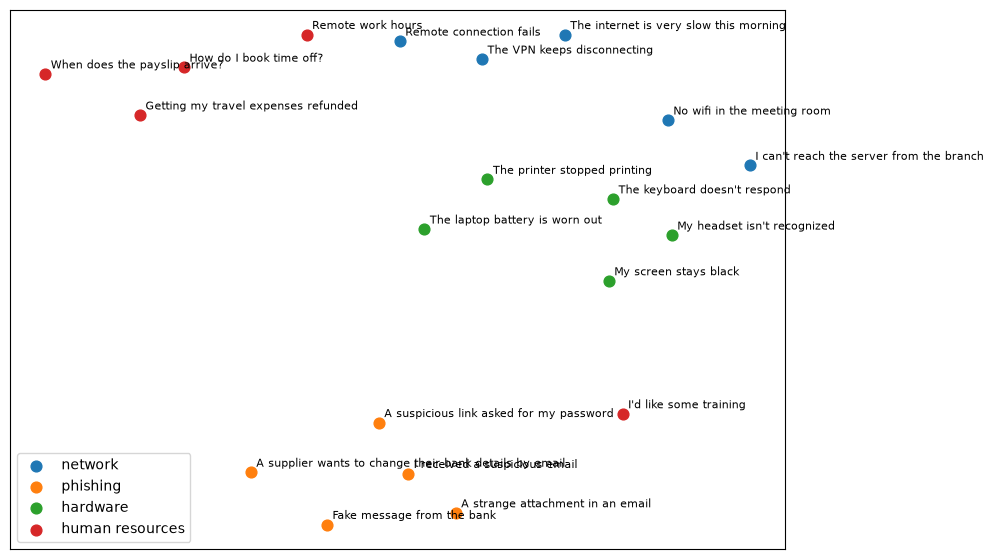

In [4]:
SENTENCES = {
    "network": ["The VPN keeps disconnecting", "No wifi in the meeting room",
                "The internet is very slow this morning", "I can't reach the server from the branch",
                "Remote connection fails"],
    "phishing": ["I received a suspicious email", "A suspicious link asked for my password",
                 "Fake message from the bank", "A supplier wants to change their bank details by email",
                 "A strange attachment in an email"],
    "hardware": ["The printer stopped printing", "My screen stays black",
                 "The keyboard doesn't respond", "The laptop battery is worn out",
                 "My headset isn't recognized"],
    "human resources": ["How do I book time off?", "When does the payslip arrive?",
                        "I'd like some training", "Getting my travel expenses refunded",
                        "Remote work hours"],
}
texts = [s for group in SENTENCES.values() for s in group]
topics = [topic for topic, group in SENTENCES.items() for _ in group]
vectors = embed(texts)
points = TSNE(n_components=2, perplexity=5, init="pca", random_state=0).fit_transform(vectors)

fig, ax = plt.subplots(figsize=(10, 7))
for topic in SENTENCES:
    mask = np.array(topics) == topic
    ax.scatter(points[mask, 0], points[mask, 1], label=topic, s=60)
for (x, y), text in zip(points, texts):
    ax.annotate(text, (x, y), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.legend()
ax.set_xticks([])
ax.set_yticks([])
plt.show()

## Searching by keywords or by meaning

A small IT support FAQ, and two ways to search it: count the words in common with the question, or compare the vectors.

In [5]:
FAQ = [
    "VPN: to work remotely, install the VPN client and sign in with your Windows account.",
    "VPN error code -7200: the server certificate changed, update the client.",
    "VPN error code -7250: the account is locked, wait 30 minutes.",
    "Forgotten password: reset it on the self-service portal.",
    "Two-factor authentication: if you change phones, contact support.",
    "Suspicious email: don't click, report it with Outlook's Report button.",
    "Lost or stolen computer: notify support and security immediately.",
    "Printers: the list of printers per floor is on the intranet.",
    "Software: installation requests go through the software catalog.",
    "Mailbox full: archive old messages or ask for more space.",
    "Guest wifi: the code changes every Monday, it is posted at reception.",
    "Remote work: loaned equipment (screen, keyboard) is requested from your manager.",
    "Shared files: access rights are granted by the folder's owner.",
]
faq_vectors = embed(FAQ, prefix="passage: ")
STOPWORDS = {"i", "my", "me", "the", "a", "an", "to", "of", "and", "or", "in", "on", "at", "from", "for",
             "with", "is", "it", "can", "can't", "no", "not", "your", "get", "got", "have", "has", "was", "be"}


def words(text: str) -> set[str]:
    return set(re.findall(r"[\w'-]+", text.lower())) - STOPWORDS


def keyword_search(question: str, k: int = 3) -> list[tuple[int, str]]:
    scores = [len(words(question) & words(entry)) for entry in FAQ]
    return [(scores[i], FAQ[i]) for i in np.argsort(scores)[::-1][:k]]


def semantic_search(question: str, k: int = 3) -> list[tuple[float, str]]:
    scores = faq_vectors @ embed(question)
    return [(round(float(scores[i]), 2), FAQ[i]) for i in np.argsort(scores)[::-1][:k]]


def compare(question: str) -> None:
    print("Question:", question)
    print("\nBy keywords (words in common):")
    for score, entry in keyword_search(question):
        print(f"  {score}  {entry}")
    print("\nBy meaning (similarity):")
    for score, entry in semantic_search(question):
        print(f"  {score}  {entry}")


compare("I can no longer get onto the office network from my house")

Question: I can no longer get onto the office network from my house

By keywords (words in common):
  0  Shared files: access rights are granted by the folder's owner.
  0  Remote work: loaned equipment (screen, keyboard) is requested from your manager.
  0  Guest wifi: the code changes every Monday, it is posted at reception.

By meaning (similarity):
  0.8  VPN: to work remotely, install the VPN client and sign in with your Windows account.
  0.79  Remote work: loaned equipment (screen, keyboard) is requested from your manager.
  0.79  VPN error code -7200: the server certificate changed, update the client.


No word of the question appears in the right answer: keyword search fails, search by meaning finds it. But the reverse happens too:

In [6]:
compare("I get error -7200")

Question: I get error -7200

By keywords (words in common):
  2  VPN error code -7200: the server certificate changed, update the client.
  1  VPN error code -7250: the account is locked, wait 30 minutes.
  0  Guest wifi: the code changes every Monday, it is posted at reception.

By meaning (similarity):
  0.88  VPN error code -7200: the server certificate changed, update the client.
  0.84  VPN error code -7250: the account is locked, wait 30 minutes.
  0.78  Mailbox full: archive old messages or ask for more space.


Search by meaning does find the right code, but by a small margin over the neighboring code: to it, two VPN error codes look alike. A code, a product reference, a proper name: keywords find them for sure, meaning not always. Production RAG systems combine both: that is **hybrid search**.

## Your turn

Ask the FAQ your own question (in Colab, the input field appears to the right of the cell).

In [7]:
QUESTION = "My computer was stolen on the train"  # @param {type: "string"}

compare(QUESTION)

Question: My computer was stolen on the train

By keywords (words in common):
  2  Lost or stolen computer: notify support and security immediately.
  0  Remote work: loaned equipment (screen, keyboard) is requested from your manager.
  0  Guest wifi: the code changes every Monday, it is posted at reception.

By meaning (similarity):
  0.82  Lost or stolen computer: notify support and security immediately.
  0.8  Remote work: loaned equipment (screen, keyboard) is requested from your manager.
  0.79  VPN error code -7200: the server certificate changed, update the client.


## Key takeaways

- An embedding places each text in a space where distance reflects meaning
- Searching by meaning finds rewordings, synonyms, other languages
- It captures the topic more than the details: negations, codes, references escape it
- Hence hybrid search (keywords and meaning), common in RAG systems